# Setting Up

In [1]:
#importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from collections import Counter

#importing the OS module
import os

#turning off the warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# saving 12 months of data in single dataframe
 
# get the list of all files and directories
path="../input/sales-dataset-of-ecommerce-electronic-products/Sales_Data"
dir_list = os.listdir(path)

files = [file for file in dir_list]
 
all_months_data = pd.DataFrame()

for file in files:
    df = pd.read_csv("../input/sales-dataset-of-ecommerce-electronic-products/Sales_Data/" + file)
    all_months_data = pd.concat([all_months_data, df])

In [3]:
#reading the dataframe
all_months_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,236670,Wired Headphones,2,11.99,08/31/19 22:21,"359 Spruce St, Seattle, WA 98101"
1,236671,Bose SoundSport Headphones,1,99.99,08/15/19 15:11,"492 Ridge St, Dallas, TX 75001"
2,236672,iPhone,1,700.0,08/06/19 14:40,"149 7th St, Portland, OR 97035"
3,236673,AA Batteries (4-pack),2,3.84,08/29/19 20:59,"631 2nd St, Los Angeles, CA 90001"
4,236674,AA Batteries (4-pack),2,3.84,08/15/19 19:53,"736 14th St, New York City, NY 10001"


In [4]:
all_months_data.tail()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
25112,319666,Lightning Charging Cable,1,14.95,12/11/19 20:58,"14 Madison St, San Francisco, CA 94016"
25113,319667,AA Batteries (4-pack),2,3.84,12/01/19 12:01,"549 Willow St, Los Angeles, CA 90001"
25114,319668,Vareebadd Phone,1,400,12/09/19 06:43,"273 Wilson St, Seattle, WA 98101"
25115,319669,Wired Headphones,1,11.99,12/03/19 10:39,"778 River St, Dallas, TX 75001"
25116,319670,Bose SoundSport Headphones,1,99.99,12/21/19 21:45,"747 Chestnut St, Los Angeles, CA 90001"


We have successfully got data from April to March (1 year) in a single dataframe.

In [5]:
all_months_data.describe(include='all').T

,count,unique,top,freq
Order ID,186305,178438,Order ID,355
Product,186305,20,USB-C Charging Cable,21903
Quantity Ordered,186305,10,1,168552
Price Each,186305,24,11.95,21903
Order Date,186305,142396,Order Date,355
Purchase Address,186305,140788,Purchase Address,355


Looks like we have some unexpected values in the Order ID, Order Date, and Purchase Address Columns, where the column title is substituted for the input. We shall clean it up.

In [6]:
all_months_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 186850 entries, 0 to 25116
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Order ID          186305 non-null  object
 1   Product           186305 non-null  object
 2   Quantity Ordered  186305 non-null  object
 3   Price Each        186305 non-null  object
 4   Order Date        186305 non-null  object
 5   Purchase Address  186305 non-null  object
dtypes: object(6)
memory usage: 10.0+ MB


# Data Cleaning

In [7]:
#checking for nan values
all_months_data.isnull().values.any(axis=1)

array([False, False, False, ..., False, False, False])

In [8]:
#counting nan values
all_months_data.isnull().sum().sum()

3270

In [9]:
#extracting rows with nan values
df_nan = all_months_data[all_months_data.isnull().values.any(axis=1)]
df_nan

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
312,NaN,NaN,NaN,NaN,NaN,NaN
1222,NaN,NaN,NaN,NaN,NaN,NaN
2648,NaN,NaN,NaN,NaN,NaN,NaN
2685,NaN,NaN,NaN,NaN,NaN,NaN
3119,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
22945,NaN,NaN,NaN,NaN,NaN,NaN
22962,NaN,NaN,NaN,NaN,NaN,NaN
23309,NaN,NaN,NaN,NaN,NaN,NaN
23996,NaN,NaN,NaN,NaN,NaN,NaN


We have entire rows with NaN values, which will not contribute to our analysis in any way.

In [10]:
#dropping rows with nan values
all_months_data = all_months_data.dropna(how = 'all')

In [11]:
all_months_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 186305 entries, 0 to 25116
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Order ID          186305 non-null  object
 1   Product           186305 non-null  object
 2   Quantity Ordered  186305 non-null  object
 3   Price Each        186305 non-null  object
 4   Order Date        186305 non-null  object
 5   Purchase Address  186305 non-null  object
dtypes: object(6)
memory usage: 9.9+ MB


In [12]:
all_months_data

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,236670,Wired Headphones,2,11.99,08/31/19 22:21,"359 Spruce St, Seattle, WA 98101"
1,236671,Bose SoundSport Headphones,1,99.99,08/15/19 15:11,"492 Ridge St, Dallas, TX 75001"
2,236672,iPhone,1,700.0,08/06/19 14:40,"149 7th St, Portland, OR 97035"
3,236673,AA Batteries (4-pack),2,3.84,08/29/19 20:59,"631 2nd St, Los Angeles, CA 90001"
4,236674,AA Batteries (4-pack),2,3.84,08/15/19 19:53,"736 14th St, New York City, NY 10001"
...,...,...,...,...,...,...
25112,319666,Lightning Charging Cable,1,14.95,12/11/19 20:58,"14 Madison St, San Francisco, CA 94016"
25113,319667,AA Batteries (4-pack),2,3.84,12/01/19 12:01,"549 Willow St, Los Angeles, CA 90001"
25114,319668,Vareebadd Phone,1,400,12/09/19 06:43,"273 Wilson St, Seattle, WA 98101"
25115,319669,Wired Headphones,1,11.99,12/03/19 10:39,"778 River St, Dallas, TX 75001"


In [13]:
#rechcking if there are rows with nan values/
df_nan1 = all_months_data[all_months_data.isnull().values.any(axis=1)]
df_nan1

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address


We have successfully cleaned all rows with NaN values.

Now, let's check for duplicate values as we noticed Purchase Address, Order Date and Order ID columns have column name in multiple places instead of the original value. 

In [14]:
#checking the order ID & Order Date columns
j = 0
k = 0
l = 0

for i in range(0, len(all_months_data)):
    oid = all_months_data['Order ID'].iloc[i]
    odt = all_months_data['Order Date'].iloc[i]
    padd = all_months_data['Purchase Address'].iloc[i]
    if oid == 'Order ID':
        k = k+1
    if odt == 'Order Date':
        j = j+1
    if padd == 'Purchase Address':
        l = l+1    
print("No of instances where column name is copied in the Order ID column:", k)
print("No of instances where column name is copied in the Order Date column:", j)
print("No of instances where column name is copied in the Purchase Address column:", l)

No of instances where column name is copied in the Order ID column: 355
No of instances where column name is copied in the Order Date column: 355
No of instances where column name is copied in the Purchase Address column: 355


Seems like we have entire rows with column names as entries. Let's check it out.

In [15]:
temp_df =all_months_data[all_months_data['Order Date'] == 'Order Date']
temp_df

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
211,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
243,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
1291,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
1412,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
1427,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
...,...,...,...,...,...,...
23198,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
23337,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
23748,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
24192,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address


Now, let's drop these 355 rows. 

In [16]:
all_months_data = all_months_data[all_months_data['Order Date'] != 'Order Date']
all_months_data

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,236670,Wired Headphones,2,11.99,08/31/19 22:21,"359 Spruce St, Seattle, WA 98101"
1,236671,Bose SoundSport Headphones,1,99.99,08/15/19 15:11,"492 Ridge St, Dallas, TX 75001"
2,236672,iPhone,1,700.0,08/06/19 14:40,"149 7th St, Portland, OR 97035"
3,236673,AA Batteries (4-pack),2,3.84,08/29/19 20:59,"631 2nd St, Los Angeles, CA 90001"
4,236674,AA Batteries (4-pack),2,3.84,08/15/19 19:53,"736 14th St, New York City, NY 10001"
...,...,...,...,...,...,...
25112,319666,Lightning Charging Cable,1,14.95,12/11/19 20:58,"14 Madison St, San Francisco, CA 94016"
25113,319667,AA Batteries (4-pack),2,3.84,12/01/19 12:01,"549 Willow St, Los Angeles, CA 90001"
25114,319668,Vareebadd Phone,1,400,12/09/19 06:43,"273 Wilson St, Seattle, WA 98101"
25115,319669,Wired Headphones,1,11.99,12/03/19 10:39,"778 River St, Dallas, TX 75001"


In [17]:
#checking the order ID & Order Date columns
j = 0
k = 0
l = 0

for i in range(0, len(all_months_data)):
    oid = all_months_data['Order ID'].iloc[i]
    odt = all_months_data['Order Date'].iloc[i]
    padd = all_months_data['Purchase Address'].iloc[i]
    if oid == 'Order ID':
        k = k+1
    if odt == 'Order Date':
        j = j+1
    if padd == 'Purchase Address':
        l = l+1    
print("No of instances where column name is copied in the Order ID column:", k)
print("No of instances where column name is copied in the Order Date column:", j)
print("No of instances where column name is copied in the Purchase Address column:", l)

No of instances where column name is copied in the Order ID column: 0
No of instances where column name is copied in the Order Date column: 0
No of instances where column name is copied in the Purchase Address column: 0


So, we have successfully cleaned the 'column name as an entry' issue.

In [18]:
#checking data types of the columns
all_months_data.dtypes

Order ID            object
Product             object
Quantity Ordered    object
Price Each          object
Order Date          object
Purchase Address    object
dtype: object

Intuitively, Quantity Ordered and Price Each columns should be numeric (integer and float data type respectively). We need to change the data type or easier calculations and analysis.

In [19]:
#converting Quanity and Price Each columns to numeric
all_months_data['Quantity Ordered'] = pd.to_numeric(all_months_data['Quantity Ordered'])
all_months_data['Price Each'] = pd.to_numeric(all_months_data['Price Each'])

In [20]:
#checking data types of the columns
all_months_data.dtypes

Order ID             object
Product              object
Quantity Ordered      int64
Price Each          float64
Order Date           object
Purchase Address     object
dtype: object

In [21]:
all_months_data

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,236670,Wired Headphones,2,11.99,08/31/19 22:21,"359 Spruce St, Seattle, WA 98101"
1,236671,Bose SoundSport Headphones,1,99.99,08/15/19 15:11,"492 Ridge St, Dallas, TX 75001"
2,236672,iPhone,1,700.00,08/06/19 14:40,"149 7th St, Portland, OR 97035"
3,236673,AA Batteries (4-pack),2,3.84,08/29/19 20:59,"631 2nd St, Los Angeles, CA 90001"
4,236674,AA Batteries (4-pack),2,3.84,08/15/19 19:53,"736 14th St, New York City, NY 10001"
...,...,...,...,...,...,...
25112,319666,Lightning Charging Cable,1,14.95,12/11/19 20:58,"14 Madison St, San Francisco, CA 94016"
25113,319667,AA Batteries (4-pack),2,3.84,12/01/19 12:01,"549 Willow St, Los Angeles, CA 90001"
25114,319668,Vareebadd Phone,1,400.00,12/09/19 06:43,"273 Wilson St, Seattle, WA 98101"
25115,319669,Wired Headphones,1,11.99,12/03/19 10:39,"778 River St, Dallas, TX 75001"


In [22]:
#converting order date to date time data type
all_months_data['Order Date'] = pd.to_datetime(all_months_data['Order Date'])
all_months_data.dtypes

Order ID                    object
Product                     object
Quantity Ordered             int64
Price Each                 float64
Order Date          datetime64[ns]
Purchase Address            object
dtype: object

We have converted the order date successfully to date time data type (which is the ideal data type).

The data set now looks good. Let's proceed with creation of new, important features.

# Adding New Features

In [23]:
#adding month column
all_months_data['Month'] = all_months_data['Order Date'].dt.month
all_months_data

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month
0,236670,Wired Headphones,2,11.99,2019-08-31 22:21:00,"359 Spruce St, Seattle, WA 98101",8
1,236671,Bose SoundSport Headphones,1,99.99,2019-08-15 15:11:00,"492 Ridge St, Dallas, TX 75001",8
2,236672,iPhone,1,700.00,2019-08-06 14:40:00,"149 7th St, Portland, OR 97035",8
3,236673,AA Batteries (4-pack),2,3.84,2019-08-29 20:59:00,"631 2nd St, Los Angeles, CA 90001",8
4,236674,AA Batteries (4-pack),2,3.84,2019-08-15 19:53:00,"736 14th St, New York City, NY 10001",8
...,...,...,...,...,...,...,...
25112,319666,Lightning Charging Cable,1,14.95,2019-12-11 20:58:00,"14 Madison St, San Francisco, CA 94016",12
25113,319667,AA Batteries (4-pack),2,3.84,2019-12-01 12:01:00,"549 Willow St, Los Angeles, CA 90001",12
25114,319668,Vareebadd Phone,1,400.00,2019-12-09 06:43:00,"273 Wilson St, Seattle, WA 98101",12
25115,319669,Wired Headphones,1,11.99,2019-12-03 10:39:00,"778 River St, Dallas, TX 75001",12


In [24]:
#adding day of the month column
all_months_data['Day'] = all_months_data['Order Date'].dt.day
all_months_data

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Day
0,236670,Wired Headphones,2,11.99,2019-08-31 22:21:00,"359 Spruce St, Seattle, WA 98101",8,31
1,236671,Bose SoundSport Headphones,1,99.99,2019-08-15 15:11:00,"492 Ridge St, Dallas, TX 75001",8,15
2,236672,iPhone,1,700.00,2019-08-06 14:40:00,"149 7th St, Portland, OR 97035",8,6
3,236673,AA Batteries (4-pack),2,3.84,2019-08-29 20:59:00,"631 2nd St, Los Angeles, CA 90001",8,29
4,236674,AA Batteries (4-pack),2,3.84,2019-08-15 19:53:00,"736 14th St, New York City, NY 10001",8,15
...,...,...,...,...,...,...,...,...
25112,319666,Lightning Charging Cable,1,14.95,2019-12-11 20:58:00,"14 Madison St, San Francisco, CA 94016",12,11
25113,319667,AA Batteries (4-pack),2,3.84,2019-12-01 12:01:00,"549 Willow St, Los Angeles, CA 90001",12,1
25114,319668,Vareebadd Phone,1,400.00,2019-12-09 06:43:00,"273 Wilson St, Seattle, WA 98101",12,9
25115,319669,Wired Headphones,1,11.99,2019-12-03 10:39:00,"778 River St, Dallas, TX 75001",12,3


In [25]:
#adding sales column
all_months_data['Sales'] = all_months_data['Quantity Ordered'] * all_months_data['Price Each']
all_months_data

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Day,Sales
0,236670,Wired Headphones,2,11.99,2019-08-31 22:21:00,"359 Spruce St, Seattle, WA 98101",8,31,23.98
1,236671,Bose SoundSport Headphones,1,99.99,2019-08-15 15:11:00,"492 Ridge St, Dallas, TX 75001",8,15,99.99
2,236672,iPhone,1,700.00,2019-08-06 14:40:00,"149 7th St, Portland, OR 97035",8,6,700.00
3,236673,AA Batteries (4-pack),2,3.84,2019-08-29 20:59:00,"631 2nd St, Los Angeles, CA 90001",8,29,7.68
4,236674,AA Batteries (4-pack),2,3.84,2019-08-15 19:53:00,"736 14th St, New York City, NY 10001",8,15,7.68
...,...,...,...,...,...,...,...,...,...
25112,319666,Lightning Charging Cable,1,14.95,2019-12-11 20:58:00,"14 Madison St, San Francisco, CA 94016",12,11,14.95
25113,319667,AA Batteries (4-pack),2,3.84,2019-12-01 12:01:00,"549 Willow St, Los Angeles, CA 90001",12,1,7.68
25114,319668,Vareebadd Phone,1,400.00,2019-12-09 06:43:00,"273 Wilson St, Seattle, WA 98101",12,9,400.00
25115,319669,Wired Headphones,1,11.99,2019-12-03 10:39:00,"778 River St, Dallas, TX 75001",12,3,11.99


In [26]:
#adding city column
all_months_data['City'] = all_months_data['Purchase Address'].apply(lambda x: x.split(',')[1])
all_months_data

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Day,Sales,City
0,236670,Wired Headphones,2,11.99,2019-08-31 22:21:00,"359 Spruce St, Seattle, WA 98101",8,31,23.98,Seattle
1,236671,Bose SoundSport Headphones,1,99.99,2019-08-15 15:11:00,"492 Ridge St, Dallas, TX 75001",8,15,99.99,Dallas
2,236672,iPhone,1,700.00,2019-08-06 14:40:00,"149 7th St, Portland, OR 97035",8,6,700.00,Portland
3,236673,AA Batteries (4-pack),2,3.84,2019-08-29 20:59:00,"631 2nd St, Los Angeles, CA 90001",8,29,7.68,Los Angeles
4,236674,AA Batteries (4-pack),2,3.84,2019-08-15 19:53:00,"736 14th St, New York City, NY 10001",8,15,7.68,New York City
...,...,...,...,...,...,...,...,...,...,...
25112,319666,Lightning Charging Cable,1,14.95,2019-12-11 20:58:00,"14 Madison St, San Francisco, CA 94016",12,11,14.95,San Francisco
25113,319667,AA Batteries (4-pack),2,3.84,2019-12-01 12:01:00,"549 Willow St, Los Angeles, CA 90001",12,1,7.68,Los Angeles
25114,319668,Vareebadd Phone,1,400.00,2019-12-09 06:43:00,"273 Wilson St, Seattle, WA 98101",12,9,400.00,Seattle
25115,319669,Wired Headphones,1,11.99,2019-12-03 10:39:00,"778 River St, Dallas, TX 75001",12,3,11.99,Dallas


Two cities in different states can have the same names. So, let's grab the corresponding states too for more accurate analysis.

In [27]:
#adding state to the city column
all_months_data['State'] = all_months_data['Purchase Address'].apply(lambda x: x.split(',')[2])
all_months_data['State'] = all_months_data['State'].apply(lambda x: x.split(' ')[1])
all_months_data['City'] = all_months_data['City'] + " (" + (all_months_data['State'])+")"
all_months_data.drop(columns = 'State', inplace = True)
all_months_data

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Day,Sales,City
0,236670,Wired Headphones,2,11.99,2019-08-31 22:21:00,"359 Spruce St, Seattle, WA 98101",8,31,23.98,Seattle (WA)
1,236671,Bose SoundSport Headphones,1,99.99,2019-08-15 15:11:00,"492 Ridge St, Dallas, TX 75001",8,15,99.99,Dallas (TX)
2,236672,iPhone,1,700.00,2019-08-06 14:40:00,"149 7th St, Portland, OR 97035",8,6,700.00,Portland (OR)
3,236673,AA Batteries (4-pack),2,3.84,2019-08-29 20:59:00,"631 2nd St, Los Angeles, CA 90001",8,29,7.68,Los Angeles (CA)
4,236674,AA Batteries (4-pack),2,3.84,2019-08-15 19:53:00,"736 14th St, New York City, NY 10001",8,15,7.68,New York City (NY)
...,...,...,...,...,...,...,...,...,...,...
25112,319666,Lightning Charging Cable,1,14.95,2019-12-11 20:58:00,"14 Madison St, San Francisco, CA 94016",12,11,14.95,San Francisco (CA)
25113,319667,AA Batteries (4-pack),2,3.84,2019-12-01 12:01:00,"549 Willow St, Los Angeles, CA 90001",12,1,7.68,Los Angeles (CA)
25114,319668,Vareebadd Phone,1,400.00,2019-12-09 06:43:00,"273 Wilson St, Seattle, WA 98101",12,9,400.00,Seattle (WA)
25115,319669,Wired Headphones,1,11.99,2019-12-03 10:39:00,"778 River St, Dallas, TX 75001",12,3,11.99,Dallas (TX)


In [28]:
#adding the order hour column
all_months_data['Hour'] = all_months_data['Order Date'].dt.hour
all_months_data

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Day,Sales,City,Hour
0,236670,Wired Headphones,2,11.99,2019-08-31 22:21:00,"359 Spruce St, Seattle, WA 98101",8,31,23.98,Seattle (WA),22
1,236671,Bose SoundSport Headphones,1,99.99,2019-08-15 15:11:00,"492 Ridge St, Dallas, TX 75001",8,15,99.99,Dallas (TX),15
2,236672,iPhone,1,700.00,2019-08-06 14:40:00,"149 7th St, Portland, OR 97035",8,6,700.00,Portland (OR),14
3,236673,AA Batteries (4-pack),2,3.84,2019-08-29 20:59:00,"631 2nd St, Los Angeles, CA 90001",8,29,7.68,Los Angeles (CA),20
4,236674,AA Batteries (4-pack),2,3.84,2019-08-15 19:53:00,"736 14th St, New York City, NY 10001",8,15,7.68,New York City (NY),19
...,...,...,...,...,...,...,...,...,...,...,...
25112,319666,Lightning Charging Cable,1,14.95,2019-12-11 20:58:00,"14 Madison St, San Francisco, CA 94016",12,11,14.95,San Francisco (CA),20
25113,319667,AA Batteries (4-pack),2,3.84,2019-12-01 12:01:00,"549 Willow St, Los Angeles, CA 90001",12,1,7.68,Los Angeles (CA),12
25114,319668,Vareebadd Phone,1,400.00,2019-12-09 06:43:00,"273 Wilson St, Seattle, WA 98101",12,9,400.00,Seattle (WA),6
25115,319669,Wired Headphones,1,11.99,2019-12-03 10:39:00,"778 River St, Dallas, TX 75001",12,3,11.99,Dallas (TX),10


In [29]:
#adding the week day column 
all_months_data['Week Day'] = all_months_data['Order Date'].dt.day_name()
all_months_data

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Day,Sales,City,Hour,Week Day
0,236670,Wired Headphones,2,11.99,2019-08-31 22:21:00,"359 Spruce St, Seattle, WA 98101",8,31,23.98,Seattle (WA),22,Saturday
1,236671,Bose SoundSport Headphones,1,99.99,2019-08-15 15:11:00,"492 Ridge St, Dallas, TX 75001",8,15,99.99,Dallas (TX),15,Thursday
2,236672,iPhone,1,700.00,2019-08-06 14:40:00,"149 7th St, Portland, OR 97035",8,6,700.00,Portland (OR),14,Tuesday
3,236673,AA Batteries (4-pack),2,3.84,2019-08-29 20:59:00,"631 2nd St, Los Angeles, CA 90001",8,29,7.68,Los Angeles (CA),20,Thursday
4,236674,AA Batteries (4-pack),2,3.84,2019-08-15 19:53:00,"736 14th St, New York City, NY 10001",8,15,7.68,New York City (NY),19,Thursday
...,...,...,...,...,...,...,...,...,...,...,...,...
25112,319666,Lightning Charging Cable,1,14.95,2019-12-11 20:58:00,"14 Madison St, San Francisco, CA 94016",12,11,14.95,San Francisco (CA),20,Wednesday
25113,319667,AA Batteries (4-pack),2,3.84,2019-12-01 12:01:00,"549 Willow St, Los Angeles, CA 90001",12,1,7.68,Los Angeles (CA),12,Sunday
25114,319668,Vareebadd Phone,1,400.00,2019-12-09 06:43:00,"273 Wilson St, Seattle, WA 98101",12,9,400.00,Seattle (WA),6,Monday
25115,319669,Wired Headphones,1,11.99,2019-12-03 10:39:00,"778 River St, Dallas, TX 75001",12,3,11.99,Dallas (TX),10,Tuesday


In [30]:
#checking dtypes once again
all_months_data.dtypes

Order ID                    object
Product                     object
Quantity Ordered             int64
Price Each                 float64
Order Date          datetime64[ns]
Purchase Address            object
Month                        int64
Day                          int64
Sales                      float64
City                        object
Hour                         int64
Week Day                    object
dtype: object

# Analysis Begins

Before going forward, let us understand a few business related concerns. 

*Orders is not the same thing as Sales.*

For example, 100 orders can be placed in a day but their combined sales can vary. It can be 10000 or 50000 depending upon the product ordered. 

Similarly, sales of 10000 can be achieved via a single order or multiple orders combined. This also depends upon the product ordered.

So, best product in terms of order and in terms of sales can be different.

### Best month in terms of sales

In [31]:
best_month = all_months_data.groupby('Month').sum()
best_month

,Quantity Ordered,Price Each,Day,Sales,Hour
Month,,,,,
1,10903,1811768.38,155814,1822256.73,139485
2,13449,2188884.72,174408,2202022.42,172669
3,17005,2791207.83,241774,2807100.38,218969
4,20558,3367671.02,282960,3390670.24,262259
5,18667,3135125.13,264875,3152606.75,238780
6,15253,2562025.61,209880,2577802.26,195528
7,16072,2632539.56,227910,2647775.76,206169
8,13448,2230345.42,192315,2244467.88,172289
9,13109,2084992.09,180101,2097560.13,168513


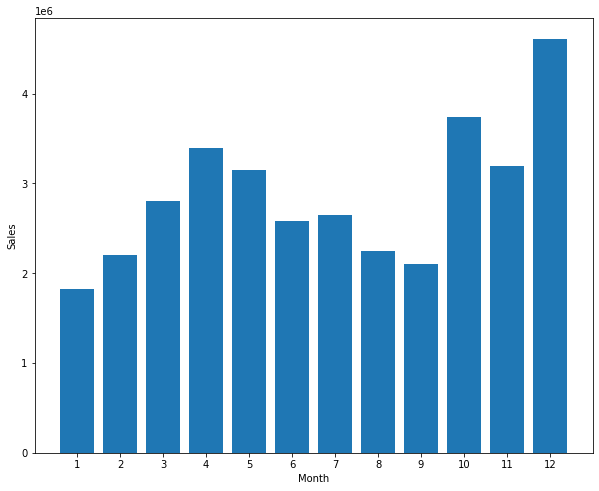

In [32]:
#visualising the monthly sales

months = range(1,13)

plt.figure(figsize=(10, 8))
plt.bar(months, best_month['Sales'])
plt.xticks(months)
plt.ylabel("Sales")
plt.xlabel("Month")
plt.show()

December was the best month in terms of sales. One of the reasons for this is the Christmas celebrations.

### Best month in terms of orders

In [33]:
#creating a subset dataframe and adding counter to it

order_count = all_months_data[['Order ID', 'Month']]

order_count['Counter'] = 1

order_count

,Order ID,Month,Counter
0,236670,8,1
1,236671,8,1
2,236672,8,1
3,236673,8,1
4,236674,8,1
...,...,...,...
25112,319666,12,1
25113,319667,12,1
25114,319668,12,1
25115,319669,12,1


In [34]:
max_order_month = order_count.groupby('Month').sum()
max_order_month

,Counter
Month,
1,9709
2,11975
3,15153
4,18279
5,16566
6,13554
7,14293
8,11961
9,11621


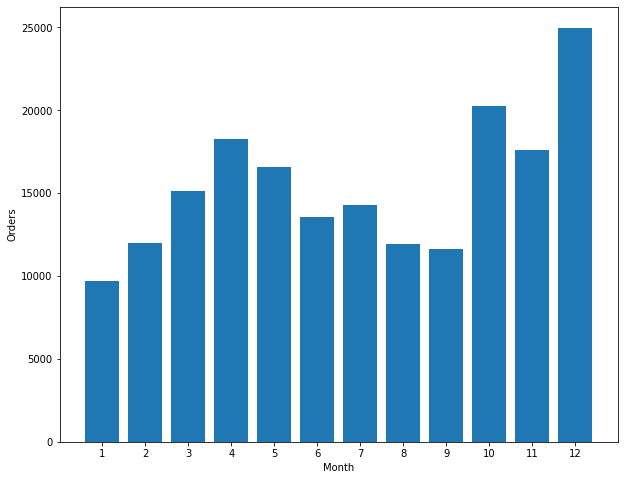

In [35]:
#visualising the monthly orders

months = range(1,13)

plt.figure(figsize=(10, 8))
plt.bar(months, max_order_month['Counter'])
plt.xticks(months)
plt.ylabel("Orders")
plt.xlabel("Month")
plt.show()

So, maximum orders were also placed in December. This is again due to the festive season. People buy for themselves, their families and for gifting.

### Best city in terms of sales

In [36]:
best_city = all_months_data.groupby('City').sum()
best_city

,Quantity Ordered,Price Each,Month,Day,Sales,Hour
City,,,,,,
Atlanta (GA),16602,2779908.20,104794,234837,2795498.58,214264
Austin (TX),11153,1809873.61,69829,156782,1819581.75,141946
Boston (MA),22528,3637409.77,141112,312376,3661642.01,288225
Dallas (TX),16730,2752627.82,104620,234435,2767975.40,214390
Los Angeles (CA),33289,5421435.23,208325,469607,5452570.80,427444
New York City (NY),27932,4635370.83,175741,392706,4664317.43,357696
Portland (ME),2750,447189.25,17144,38288,449758.27,35211
Portland (OR),11303,1860558.22,70621,159233,1870732.34,144421
San Francisco (CA),50239,8211461.74,315520,702669,8262203.91,643265


Clearly, San Francisco has the highest sales. If you wonder at the reason, one can be the high requirements of electronics (which have high prices) in the Silicon Valley. Also, maybe people have more money in San Francisco.

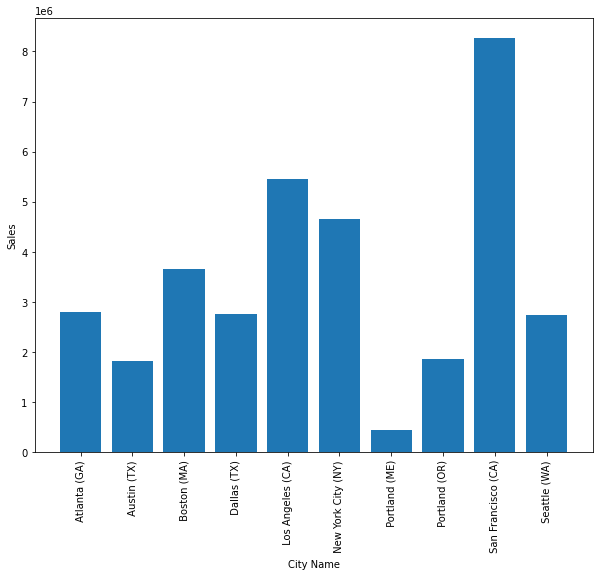

In [37]:
#visualising the city wise sales

cities = [city for city, df in all_months_data.groupby('City')]

plt.figure(figsize=(10, 8))
plt.bar(cities, best_city['Sales'])
plt.xticks(cities, rotation = 'vertical')
plt.ylabel("Sales")
plt.xlabel("City Name")
plt.show() 

### Best city in terms of orders

In [38]:
#creating a subset dataframe and adding counter to it

city_order_count = all_months_data[['Order ID', 'City']]

city_order_count['Counter'] = 1

city_order_count

,Order ID,City,Counter
0,236670,Seattle (WA),1
1,236671,Dallas (TX),1
2,236672,Portland (OR),1
3,236673,Los Angeles (CA),1
4,236674,New York City (NY),1
...,...,...,...
25112,319666,San Francisco (CA),1
25113,319667,Los Angeles (CA),1
25114,319668,Seattle (WA),1
25115,319669,Dallas (TX),1


In [39]:
max_order_city = city_order_count.groupby('City').sum()
max_order_city

,Counter
City,
Atlanta (GA),14881
Austin (TX),9905
Boston (MA),19934
Dallas (TX),14820
Los Angeles (CA),29605
New York City (NY),24876
Portland (ME),2455
Portland (OR),10010
San Francisco (CA),44732


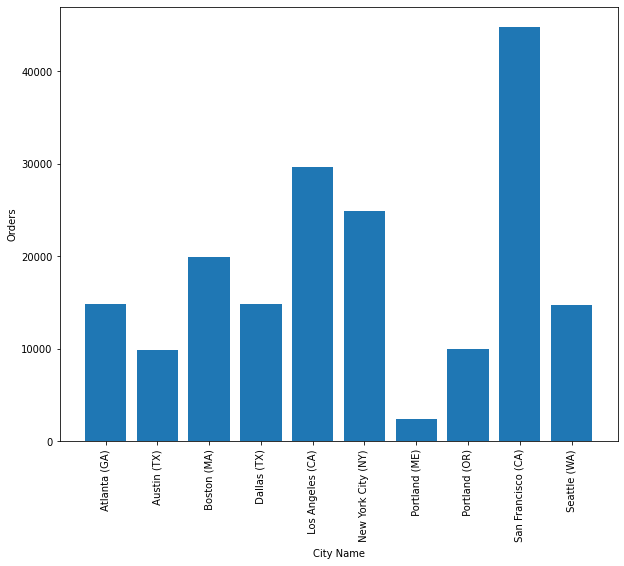

In [40]:
#visualising the city wise orders

plt.figure(figsize=(10, 8))
plt.bar(cities, max_order_city['Counter'])
plt.xticks(cities, rotation = 'vertical')
plt.ylabel("Orders")
plt.xlabel("City Name")
plt.show()

Interestingly, San Fransisco has highest number of orders too. This can be credited to the lifestyle and needs of the people living there.

### Best timings for advertisements to get maximum conversions

In [41]:
all_months_data['Counter'] = 1
best_hour = all_months_data.groupby('Hour').count()
best_hour

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Day,Sales,City,Week Day,Counter
Hour,,,,,,,,,,,,
0,3910,3910,3910,3910,3910,3910,3910,3910,3910,3910,3910,3910
1,2350,2350,2350,2350,2350,2350,2350,2350,2350,2350,2350,2350
2,1243,1243,1243,1243,1243,1243,1243,1243,1243,1243,1243,1243
3,831,831,831,831,831,831,831,831,831,831,831,831
4,854,854,854,854,854,854,854,854,854,854,854,854
5,1321,1321,1321,1321,1321,1321,1321,1321,1321,1321,1321,1321
6,2482,2482,2482,2482,2482,2482,2482,2482,2482,2482,2482,2482
7,4011,4011,4011,4011,4011,4011,4011,4011,4011,4011,4011,4011
8,6256,6256,6256,6256,6256,6256,6256,6256,6256,6256,6256,6256


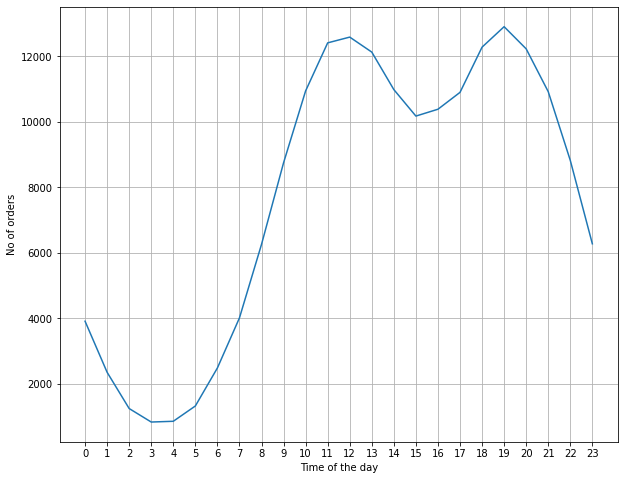

In [42]:
#visualizing hourly orders placed
hours= [hour for hour, df in all_months_data.groupby('Hour')]

plt.figure(figsize=(10, 8))
plt.plot(hours, best_hour['Counter'])
plt.xticks(hours)
#plt.yticks(best_hour['Counter'])
plt.xlabel('Time of the day')
plt.ylabel('No of orders')
plt.grid()
plt.show()

The best timings for advertisements are between 10 am to 1 pm (when people usually have their lunch and are scrolling their mobile devices) and 6 pm to 8 pm (when people are off work, having dinners or hanging out and using their mobile devices).

### Best day of the week in terms of sales

In [43]:
best_weekday = all_months_data.groupby('Week Day').sum()
best_weekday

,Quantity Ordered,Price Each,Month,Day,Sales,Hour,Counter
Week Day,,,,,,,
Friday,29448,4830795.59,184699,406175,4855938.38,379231,26247
Monday,29899,4850763.70,190462,412319,4883326.72,382210,26547
Saturday,29769,4873105.48,185836,422299,4904357.01,382019,26492
Sunday,29778,4903226.77,188819,419189,4932169.66,384250,26551
Thursday,29662,4810040.26,185521,426891,4839465.16,380961,26461
Tuesday,30724,5061153.03,193238,428748,5087956.78,390675,27175
Wednesday,29799,4960045.85,184072,414864,4988822.26,380808,26477


In [44]:
#arranging days in weekday order
days = [ 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

best_weekday = best_weekday.reindex(days) 
best_weekday

,Quantity Ordered,Price Each,Month,Day,Sales,Hour,Counter
Week Day,,,,,,,
Monday,29899,4850763.70,190462,412319,4883326.72,382210,26547
Tuesday,30724,5061153.03,193238,428748,5087956.78,390675,27175
Wednesday,29799,4960045.85,184072,414864,4988822.26,380808,26477
Thursday,29662,4810040.26,185521,426891,4839465.16,380961,26461
Friday,29448,4830795.59,184699,406175,4855938.38,379231,26247
Saturday,29769,4873105.48,185836,422299,4904357.01,382019,26492
Sunday,29778,4903226.77,188819,419189,4932169.66,384250,26551


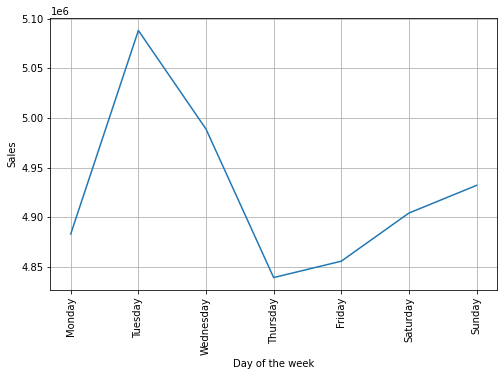

In [45]:
#visualizing day-wise sales

plt.figure(figsize=(8, 5))
plt.plot(days, best_weekday['Sales'])
plt.xticks(days, rotation = 'vertical')
plt.xlabel('Day of the week')
plt.ylabel('Sales')
plt.grid()
plt.show()

Maximum sales happens on Tuesdays. Let's correlate this with the pattern of orders placed during the week.

### Best day of the week in terms of orders

In [46]:
best_day = all_months_data.groupby('Week Day').count()
best_day

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Day,Sales,City,Hour,Counter
Week Day,,,,,,,,,,,,
Friday,26247,26247,26247,26247,26247,26247,26247,26247,26247,26247,26247,26247
Monday,26547,26547,26547,26547,26547,26547,26547,26547,26547,26547,26547,26547
Saturday,26492,26492,26492,26492,26492,26492,26492,26492,26492,26492,26492,26492
Sunday,26551,26551,26551,26551,26551,26551,26551,26551,26551,26551,26551,26551
Thursday,26461,26461,26461,26461,26461,26461,26461,26461,26461,26461,26461,26461
Tuesday,27175,27175,27175,27175,27175,27175,27175,27175,27175,27175,27175,27175
Wednesday,26477,26477,26477,26477,26477,26477,26477,26477,26477,26477,26477,26477


Since the dataframe displays 'Week Day' in alphabetical order, let us sort and display it in proper weekday order.

In [47]:
#arranging days in weekday order
days = [ 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

best_day = best_day.reindex(days) 
best_day

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Day,Sales,City,Hour,Counter
Week Day,,,,,,,,,,,,
Monday,26547,26547,26547,26547,26547,26547,26547,26547,26547,26547,26547,26547
Tuesday,27175,27175,27175,27175,27175,27175,27175,27175,27175,27175,27175,27175
Wednesday,26477,26477,26477,26477,26477,26477,26477,26477,26477,26477,26477,26477
Thursday,26461,26461,26461,26461,26461,26461,26461,26461,26461,26461,26461,26461
Friday,26247,26247,26247,26247,26247,26247,26247,26247,26247,26247,26247,26247
Saturday,26492,26492,26492,26492,26492,26492,26492,26492,26492,26492,26492,26492
Sunday,26551,26551,26551,26551,26551,26551,26551,26551,26551,26551,26551,26551


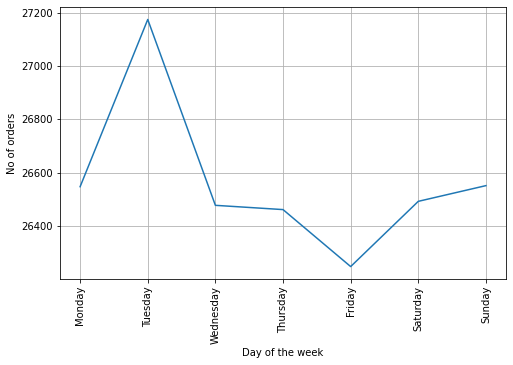

In [48]:
#visualizing day-wise orders placed

plt.figure(figsize=(8, 5))
plt.plot(days, best_day['Counter'])
plt.xticks(days, rotation = 'vertical')
plt.xlabel('Day of the week')
plt.ylabel('No of orders')
plt.grid()
plt.show()

Most orders are placed by people on Tuesday (which is strange). One of the reason can be the weekend! Yes, the weekend is certainly the quietest time for orders, as people have more leisure time. So when they are back, they attend to their professional needs and place orders. 

### Hot dates to sell every month

In [49]:
hot_dates = all_months_data[['Order ID', 'Day']]
hot_dates['Counter'] = 1
hot_dates

,Order ID,Day,Counter
0,236670,31,1
1,236671,15,1
2,236672,6,1
3,236673,29,1
4,236674,15,1
...,...,...,...
25112,319666,11,1
25113,319667,1,1
25114,319668,9,1
25115,319669,3,1


In [50]:
hot_dates_sales = hot_dates.groupby('Day').sum()
hot_dates_sales

,Counter
Day,
1,6051
2,6197
3,5819
4,6066
5,6020
6,6088
7,6033
8,6073
9,6114


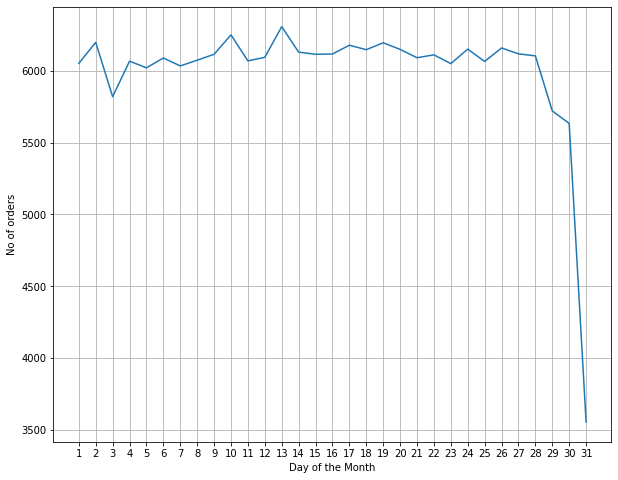

In [51]:
#visualizing date wise orders placed
dates = [date for date, df in all_months_data.groupby('Day')]

plt.figure(figsize=(10, 8))
plt.plot(dates, hot_dates_sales['Counter'])
plt.xticks(dates)
plt.xlabel('Day of the Month')
plt.ylabel('No of orders')
plt.grid()
plt.show()

We have peaks on the 2nd, 10th and 13th of a particular month. These can be hot dates to promote products and get orders. Also, end of the month sees a sharp decine in the number of orders (maybe people are waiting for their salaries).

### Most Ordered Product

In [52]:
product_group = all_months_data.groupby('Product')
most_orders = product_group.sum()['Quantity Ordered']

most_orders

Product
20in Monitor                   4129
27in 4K Gaming Monitor         6244
27in FHD Monitor               7550
34in Ultrawide Monitor         6199
AA Batteries (4-pack)         27635
AAA Batteries (4-pack)        31017
Apple Airpods Headphones      15661
Bose SoundSport Headphones    13457
Flatscreen TV                  4819
Google Phone                   5532
LG Dryer                        646
LG Washing Machine              666
Lightning Charging Cable      23217
Macbook Pro Laptop             4728
ThinkPad Laptop                4130
USB-C Charging Cable          23975
Vareebadd Phone                2068
Wired Headphones              20557
iPhone                         6849
Name: Quantity Ordered, dtype: int64

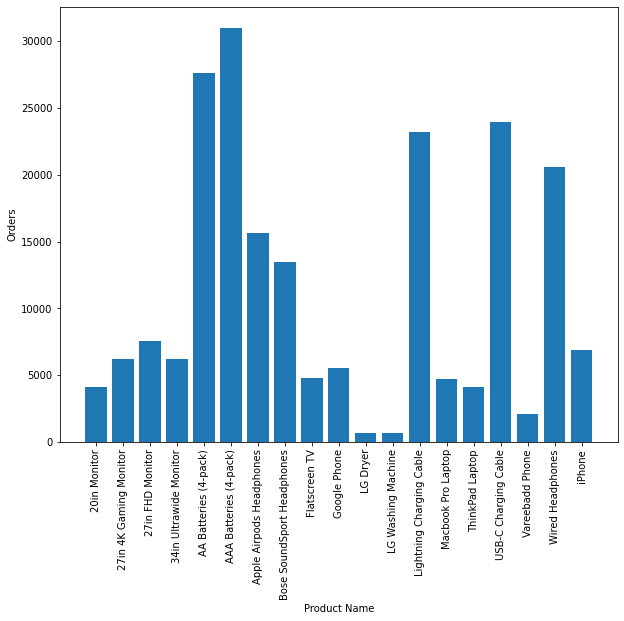

In [53]:
#visualising the most ordered products

product = [product for product, df in product_group]

plt.figure(figsize=(10, 8))
plt.bar(product, most_orders)
plt.xticks(product, rotation = 'vertical')
plt.ylabel("Orders")
plt.xlabel("Product Name")
plt.show() 

The most ordered product are AAA batteries. They are most often used in small electronic devices, such as TV remote controls, MP3 players and digital cameras, toys, thermometers, etc. Also, they are not very costly.

In [54]:
#finding mean price of each product
prices = all_months_data.groupby('Product').mean()['Price Each']

prices

Product
20in Monitor                   109.99
27in 4K Gaming Monitor         389.99
27in FHD Monitor               149.99
34in Ultrawide Monitor         379.99
AA Batteries (4-pack)            3.84
AAA Batteries (4-pack)           2.99
Apple Airpods Headphones       150.00
Bose SoundSport Headphones      99.99
Flatscreen TV                  300.00
Google Phone                   600.00
LG Dryer                       600.00
LG Washing Machine             600.00
Lightning Charging Cable        14.95
Macbook Pro Laptop            1700.00
ThinkPad Laptop                999.99
USB-C Charging Cable            11.95
Vareebadd Phone                400.00
Wired Headphones                11.99
iPhone                         700.00
Name: Price Each, dtype: float64

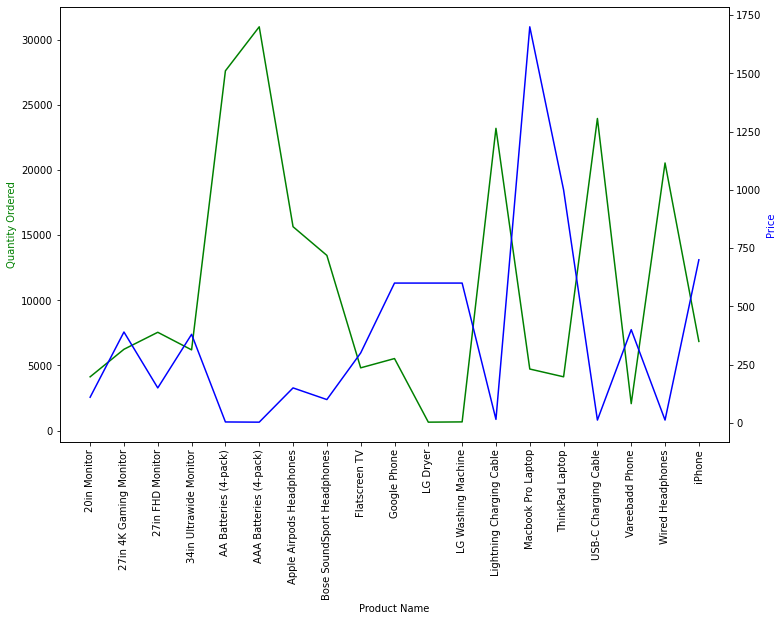

In [55]:
fig, ax1 = plt.subplots(figsize=(12, 8))

ax2 = ax1.twinx()
ax1.plot(product, most_orders, color = 'g')
ax2.plot(product, prices, color = 'b')

ax1.set_xlabel('Product Name')
ax1.set_ylabel('Quantity Ordered', color = 'g', size = 10)
ax2.set_ylabel('Price', color = 'b', size = 10)
ax1.set_xticklabels(product, rotation = 'vertical', size = 10)

plt.show()

### Product Combinations Frequently Bought Together

In [56]:
#creating a separate dataframe for order Ids with multiple orders
prod_combos = all_months_data[all_months_data['Order ID'].duplicated(keep=False)]
prod_combos

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Day,Sales,City,Hour,Week Day,Counter
46,236716,AA Batteries (4-pack),2,3.84,2019-08-17 20:12:00,"84 Cedar St, San Francisco, CA 94016",8,17,7.68,San Francisco (CA),20,Saturday,1
47,236716,USB-C Charging Cable,1,11.95,2019-08-17 20:12:00,"84 Cedar St, San Francisco, CA 94016",8,17,11.95,San Francisco (CA),20,Saturday,1
60,236729,iPhone,1,700.00,2019-08-09 09:28:00,"635 Lake St, San Francisco, CA 94016",8,9,700.00,San Francisco (CA),9,Friday,1
61,236729,Apple Airpods Headphones,1,150.00,2019-08-09 09:28:00,"635 Lake St, San Francisco, CA 94016",8,9,150.00,San Francisco (CA),9,Friday,1
62,236730,Google Phone,1,600.00,2019-08-02 10:17:00,"445 Lincoln St, New York City, NY 10001",8,2,600.00,New York City (NY),10,Friday,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
25028,319584,Wired Headphones,1,11.99,2019-12-11 00:30:00,"537 Sunset St, Portland, OR 97035",12,11,11.99,Portland (OR),0,Wednesday,1
25040,319596,iPhone,1,700.00,2019-12-01 08:44:00,"436 14th St, New York City, NY 10001",12,1,700.00,New York City (NY),8,Sunday,1
25041,319596,Lightning Charging Cable,1,14.95,2019-12-01 08:44:00,"436 14th St, New York City, NY 10001",12,1,14.95,New York City (NY),8,Sunday,1
25076,319631,34in Ultrawide Monitor,1,379.99,2019-12-17 22:35:00,"363 Highland St, Austin, TX 73301",12,17,379.99,Austin (TX),22,Tuesday,1


In [57]:
#grouping entries by order IDs
prod_combos['Combined'] = prod_combos.groupby('Order ID')['Product'].transform(lambda x: ', '.join(x))

#dropping duplicates
prod_combos = prod_combos[['Order ID', 'Combined']].drop_duplicates()

prod_combos

,Order ID,Combined
46,236716,"AA Batteries (4-pack), USB-C Charging Cable"
60,236729,"iPhone, Apple Airpods Headphones"
62,236730,"Google Phone, Wired Headphones"
132,236799,"Google Phone, Wired Headphones"
163,236829,"Vareebadd Phone, USB-C Charging Cable"
...,...,...
24977,319536,"Macbook Pro Laptop, Wired Headphones"
24998,319556,"Google Phone, Wired Headphones"
25027,319584,"iPhone, Wired Headphones"
25040,319596,"iPhone, Lightning Charging Cable"


In [58]:
#counting unique pairs of products

count = Counter()

for row in prod_combos['Combined']:
    row_list = row.split(', ')
    count.update(Counter(combinations(row_list,2)))

count.most_common(10)

[(('iPhone', 'Lightning Charging Cable'), 1005),
 (('Google Phone', 'USB-C Charging Cable'), 987),
 (('iPhone', 'Wired Headphones'), 447),
 (('Google Phone', 'Wired Headphones'), 414),
 (('Vareebadd Phone', 'USB-C Charging Cable'), 361),
 (('iPhone', 'Apple Airpods Headphones'), 360),
 (('Google Phone', 'Bose SoundSport Headphones'), 220),
 (('USB-C Charging Cable', 'Wired Headphones'), 160),
 (('Vareebadd Phone', 'Wired Headphones'), 143),
 (('Lightning Charging Cable', 'Wired Headphones'), 92)]

In [59]:
#counting unique triplets of products

count1 = Counter()

for row in prod_combos['Combined']:
    row_list1 = row.split(', ')
    count1.update(Counter(combinations(row_list1,3)))

count1.most_common(10)

[(('Google Phone', 'USB-C Charging Cable', 'Wired Headphones'), 87),
 (('iPhone', 'Lightning Charging Cable', 'Wired Headphones'), 62),
 (('iPhone', 'Lightning Charging Cable', 'Apple Airpods Headphones'), 47),
 (('Google Phone', 'USB-C Charging Cable', 'Bose SoundSport Headphones'), 35),
 (('Vareebadd Phone', 'USB-C Charging Cable', 'Wired Headphones'), 33),
 (('iPhone', 'Apple Airpods Headphones', 'Wired Headphones'), 27),
 (('Google Phone', 'Bose SoundSport Headphones', 'Wired Headphones'), 24),
 (('Vareebadd Phone', 'USB-C Charging Cable', 'Bose SoundSport Headphones'),
  16),
 (('USB-C Charging Cable', 'Bose SoundSport Headphones', 'Wired Headphones'),
  5),
 (('Vareebadd Phone', 'Bose SoundSport Headphones', 'Wired Headphones'), 5)]

This gives you insights into what products can be sold together at a certain discount or if a user is viewing a product/has purchased a product, which other products can be shown in recommendations. You can also target people based on this for your advertisements.

# THE END